# PCA vs LDA vs t-SNE — Visual Comparison

Three ways to squash the 4D Iris dataset into 2D so we can *look* at it. This notebook
is about **visualization only** — no classifier, no accuracy numbers (see
`pca_vs_lda_explained.md` for why t-SNE doesn't belong in an accuracy comparison).

| Method | Supervised? | Linear? | Keeps... |
|---|---|---|---|
| **PCA** | ❌ no | ✅ yes | directions of maximum **variance** |
| **LDA** | ✅ yes | ✅ yes | directions of maximum **class separation** |
| **t-SNE** | ❌ no | ❌ no | local **neighborhoods** (who's close to whom) |

> ⚠️ **t-SNE is for viewing, not for features.** It has no `transform` for new points,
> it's stochastic (depends on the random seed and *perplexity*), and distances/areas
> between clusters aren't meaningful. Great for spotting clusters, not for modeling.

In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load Iris and standardize (all methods benefit from standardized features)
data = load_iris()
X = data.data
y = data.target
target_names = data.target_names

X_scaled = StandardScaler().fit_transform(X)
print(f"Data: {X.shape}, classes: {list(target_names)}")

Data: (150, 4), classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [3]:
# PCA -> 2D (unsupervised, no labels)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# LDA -> 2D (supervised, uses y; max components = n_classes - 1 = 2)
X_lda = LinearDiscriminantAnalysis(n_components=2).fit_transform(X_scaled, y)

# t-SNE -> 2D (unsupervised, non-linear). perplexity ~ how many neighbors matter.
# random_state fixes the seed so the picture is reproducible.
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(X_scaled)

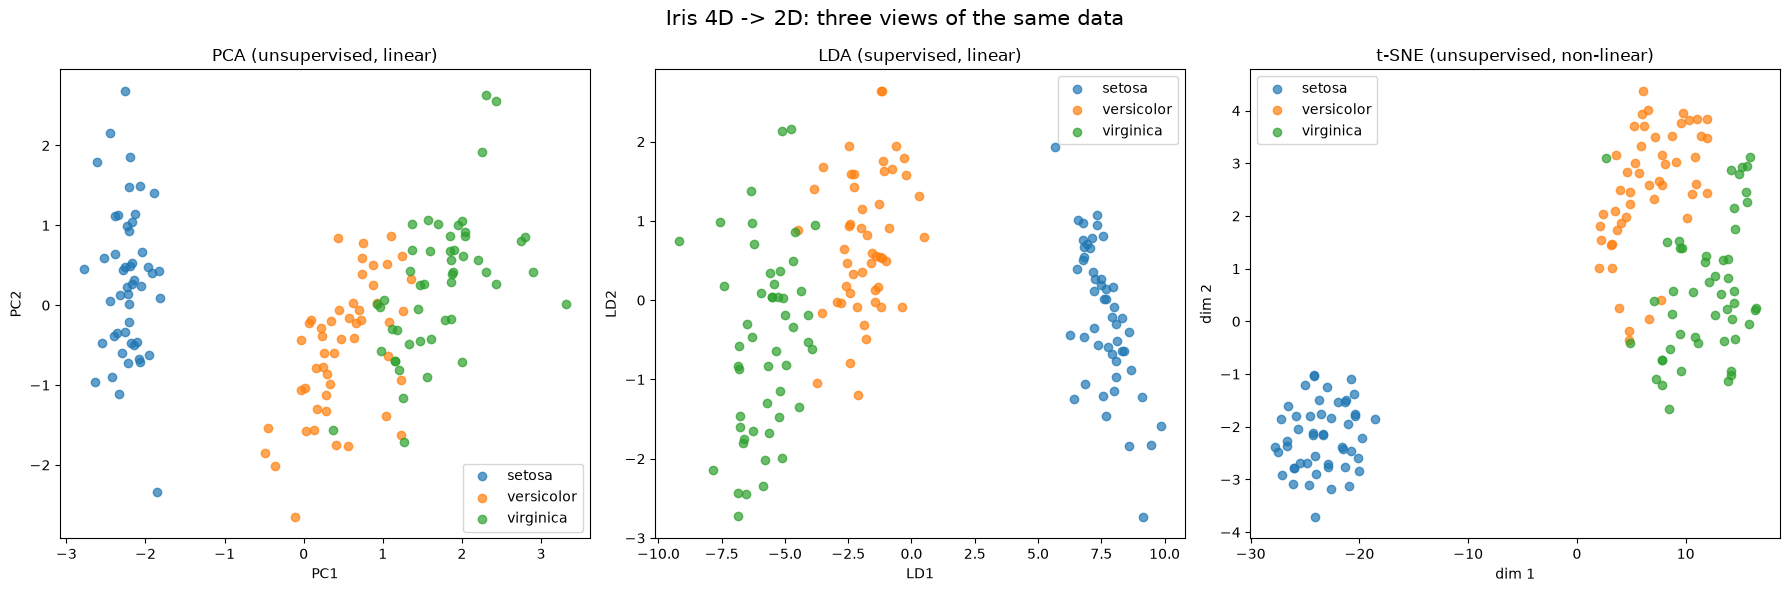

In [4]:
projections = [
    (X_pca,  "PCA (unsupervised, linear)",   "PC1",  "PC2"),
    (X_lda,  "LDA (supervised, linear)",     "LD1",  "LD2"),
    (X_tsne, "t-SNE (unsupervised, non-linear)", "dim 1", "dim 2"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (proj, title, xl, yl) in zip(axes, projections):
    for label in [0, 1, 2]:
        m = y == label
        ax.scatter(proj[m, 0], proj[m, 1], label=target_names[label], alpha=0.7)
    ax.set(title=title, xlabel=xl, ylabel=yl)
    ax.legend()

plt.suptitle("Iris 4D -> 2D: three views of the same data", fontsize=15)
plt.tight_layout()
plt.show()

## t-SNE is sensitive to *perplexity*

Perplexity roughly controls how many neighbors each point pays attention to. Small
values emphasize tiny local clusters; large values look more global. There's no single
"right" value — which is exactly why t-SNE is a viewing tool, not a fixed transform.

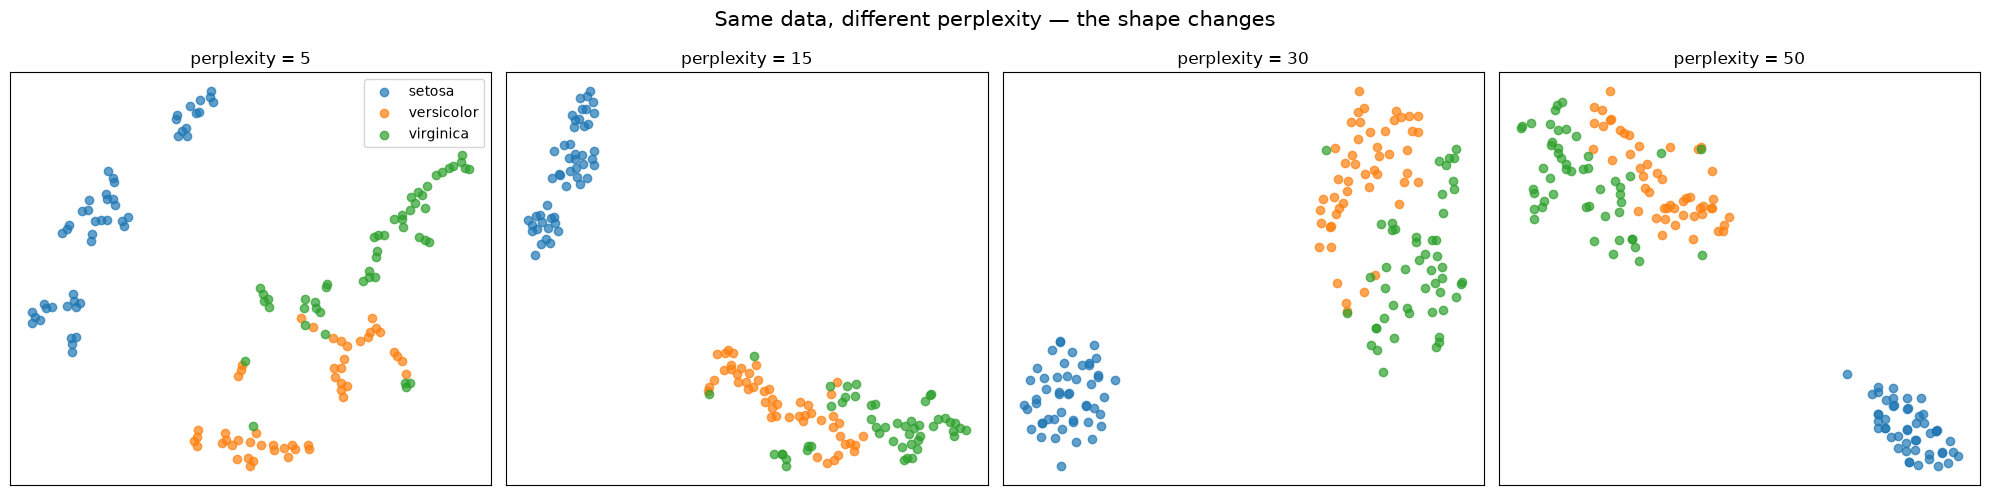

In [5]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(20, 5))
for ax, p in zip(axes, perplexities):
    emb = TSNE(n_components=2, perplexity=p, random_state=42, init="pca").fit_transform(X_scaled)
    for label in [0, 1, 2]:
        m = y == label
        ax.scatter(emb[m, 0], emb[m, 1], label=target_names[label], alpha=0.7)
    ax.set_title(f"perplexity = {p}")
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend()
plt.suptitle("Same data, different perplexity — the shape changes", fontsize=15)
plt.tight_layout()
plt.show()

## What to notice

- **PCA** — *setosa* splits off cleanly; *versicolor* and *virginica* overlap a bit.
  It never saw the labels, so any separation is a happy side effect of variance.
- **LDA** — the tightest, most separated clumps, because it *used* the labels to pick
  axes that pull the classes apart. Limited to 2 axes here (`n_classes - 1`).
- **t-SNE** — often shows three well-isolated blobs, but the **gaps and sizes between
  blobs are not meaningful**, and the layout shifts with perplexity and the random seed.

**Bottom line:** use **PCA** to explore unlabeled data, **LDA** when you have labels and
want class separation (and reusable features), and **t-SNE** purely to eyeball cluster
structure — never as input to a model.